# **Project Overview: Student Career Path & Placement Analytics**

### **Problem Statement**
In today's competitive job market, understanding the factors that lead to successful student placement is crucial for both educational institutions and students. The challenge lies in accurately predicting a student's placement outcome by analyzing a complex interplay of academic performance (such as CGPA and standardized scores) and extracurricular involvement (such as internships, projects, and certifications). Identifying which specific attributes most significantly impact employability remains a key hurdle in optimizing career readiness programs.

### **Objective**
The primary objective of this project is to perform a comprehensive Exploratory Data Analysis (EDA) to uncover patterns and correlations within the student data. Following the analysis, we aim to build and compare predictive models—specifically **Logistic Regression** and **Decision Trees**—to classify students as 'Placed' or 'Not Placed'. By doing so, we intend to identify the key placement drivers and provide actionable insights into how students can improve their chances of securing employment.

## Environment Setup

### Subtask:
Import the necessary Python libraries required for data manipulation, statistical analysis, visualization, and machine learning.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

%matplotlib inline

print('Libraries imported successfully.')

Libraries imported successfully.


## Data Loading and Initial Stats

### Subtask:
Load the placement dataset and calculate descriptive statistics for academic scores using Pandas and NumPy.


In [ ]:
# Load the dataset
df = pd.read_csv('Placement_Data_Final.csv')

# Extract 'Total_Academic_Score' as a NumPy array
academic_scores = df['Total_Academic_Score'].values

# Calculate descriptive statistics using NumPy
mean_score = np.mean(academic_scores)
median_score = np.median(academic_scores)
std_dev_score = np.std(academic_scores)

# Print the statistics
print(f'Mean Academic Score: {mean_score:.2f}')
print(f'Median Academic Score: {median_score:.2f}')
print(f'Standard Deviation of Academic Score: {std_dev_score:.2f}')

# Display the first few rows of the dataframe
display(df.head())

Mean Academic Score: 156.43
Median Academic Score: 157.00
Standard Deviation of Academic Score: 12.48


,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus,Total_Academic_Score
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced,140
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed,179
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced,155
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed,160
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed,169


## Domain Analysis and Basic Checks

### Subtask:
Document feature context and perform initial data inspection using pandas methods.


### **Feature Descriptions**

Understanding the variables in our dataset is essential for interpreting the analysis results:

*   **CGPA**: The Cumulative Grade Point Average of the student, representing academic consistency.
*   **Internships**: The number of professional internships the student has completed.
*   **Projects**: The count of academic or independent projects undertaken by the student.
*   **AptitudeTestScore**: Scores obtained in standardized aptitude tests, often used as a primary screening tool by recruiters.
*   **SoftSkillsRating**: A score (typically 1-5) representing the student's communication and interpersonal abilities.
*   **PlacementStatus**: The target variable indicating whether a student was 'Placed' or 'NotPlaced'.

Perform the initial data inspection using pandas methods like info(), describe(), and shape to understand the dataset structure and statistics.



In [ ]:
print('--- Dataset Info ---')
print(df.info())

print('\n--- Summary Statistics ---')
display(df.describe())

print('\n--- Dataset Shape ---')
print(f'Total records: {df.shape[0]}')
print(f'Total features: {df.shape[1]}')

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
 12  Total_Academic_Score       10000 non-null  int64  
dtypes: float64(2), int64(8), o

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks,Total_Academic_Score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,69.159400,74.501500,156.430000
std,2886.89568,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,10.430459,8.919527,12.479939
min,1.00000,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,55.000000,57.000000,125.000000
25%,2500.75000,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,59.000000,67.000000,147.000000
50%,5000.50000,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,70.000000,73.000000,157.000000
75%,7500.25000,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,78.000000,83.000000,167.000000
max,10000.00000,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,90.000000,88.000000,181.000000



--- Dataset Shape ---
Total records: 10000
Total features: 13


# Task
Clean the dataset "Placement_Data_Final.csv" and conduct exploratory data analysis (EDA) to identify key placement drivers. The cleaning process should handle missing values using `fillna()`, remove duplicates, rename columns for clarity (e.g., changing `SSC_Marks` to `Secondary_School_Marks`). Perform univariate analysis using histograms for academic scores, count plots for placement status, and box plots with NumPy-based filtering to detect outliers. Conduct bivariate and multivariate analyses using scatter plots (Score vs. Status), bar plots (Placement by Field), pairplots, and a Seaborn heatmap to identify correlations, ensuring all plots include legends. Add a markdown cell summarizing key trends and placement drivers discovered. Finally, implement and train both a Logistic Regression model and a Decision Tree Classifier, evaluating their performance with accuracy scores and confusion matrices to determine the factors most critical to student placement success.

## Data Cleaning and Wrangling

### Subtask:
Clean the dataset by handling missing values, removing duplicates, and renaming columns for clarity.


In [ ]:
# 1. Handle missing values
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 2. Remove duplicates
df.drop_duplicates(inplace=True)

# 3. Rename columns for clarity (Permanent change)
rename_dict = {
    'SSC_Marks': 'Secondary_School_Marks',
    'HSC_Marks': 'Higher_Secondary_Marks',
    'Workshops/Certifications': 'Certifications',
    'AptitudeTestScore': 'Aptitude_Score',
    'SoftSkillsRating': 'Soft_Skills_Rating',
    'ExtracurricularActivities': 'Extracurricular_Activities',
    'PlacementTraining': 'Placement_Training',
    'PlacementStatus': 'Placement_Status'
}
df.rename(columns=rename_dict, inplace=True)

print('Data cleaned and columns renamed permanently.')
display(df.head())

Data cleaned and columns renamed permanently.


,StudentID,CGPA,Internships,Projects,Certifications,Aptitude_Score,Soft_Skills_Rating,Extracurricular_Activities,Placement_Training,Secondary_School_Marks,Higher_Secondary_Marks,Placement_Status,Total_Academic_Score
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced,140
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed,179
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced,155
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed,160
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed,169


## Univariate Analysis

### Subtask:
Perform univariate analysis using histograms for academic scores, count plots for placement status, and box plots with NumPy-based filtering to detect outliers.


Perform univariate analysis by creating a multi-panel visualization including a histogram for academic scores, a count plot for placement status, and a box plot with manual IQR-based outlier detection as requested in the subtask instructions.



Outliers detected: 0


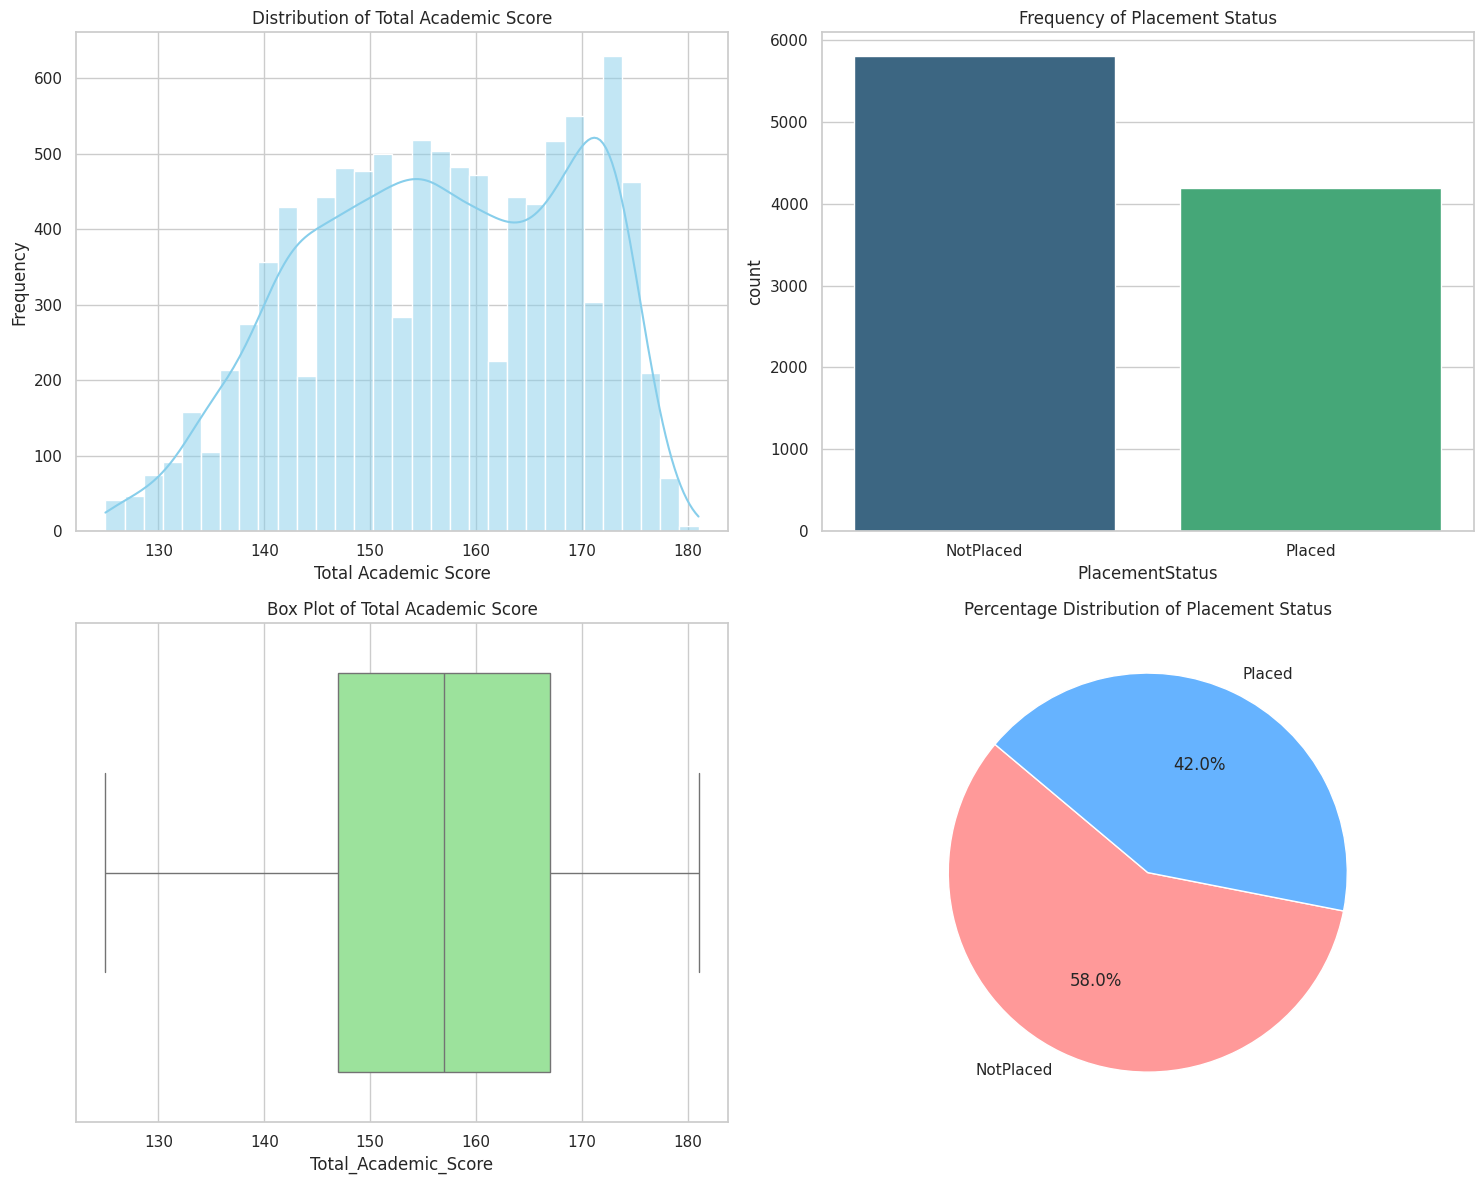

In [ ]:
# Setting the aesthetic style
sns.set_theme(style='whitegrid')

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Histogram for Total_Academic_Score
sns.histplot(df['Total_Academic_Score'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Total Academic Score')
axes[0, 0].set_xlabel('Total Academic Score')
axes[0, 0].set_ylabel('Frequency')

# 2. Count plot for Placement_Status - Using the current column name from the df
status_col = 'Placement_Status' if 'Placement_Status' in df.columns else 'PlacementStatus'
sns.countplot(data=df, x=status_col, ax=axes[0, 1], palette='viridis', hue=status_col, legend=False)
axes[0, 1].set_title('Frequency of Placement Status')

# 3. Outlier detection using NumPy
q1, q3 = np.percentile(df['Total_Academic_Score'], [25, 75])
iqr = q3 - q1
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
outliers = df[(df['Total_Academic_Score'] < lower_bound) | (df['Total_Academic_Score'] > upper_bound)]
print(f'Outliers detected: {len(outliers)}')

# 4. Box plot
sns.boxplot(x=df['Total_Academic_Score'], ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Box Plot of Total Academic Score')

# 5. Pie chart
placement_counts = df[status_col].value_counts()
axes[1, 1].pie(placement_counts, labels=placement_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
axes[1, 1].set_title('Percentage Distribution of Placement Status')

plt.tight_layout()
plt.show()

In [ ]:
# Exporting the finalized dataframe
csv_file_name = 'Placement_Analysis_Results.csv'
df.to_csv(csv_file_name, index=False)

print(f'Successfully exported with updated names: {df.columns.tolist()[:3]}...')

Successfully exported with updated names: ['StudentID', 'CGPA', 'Internships']...


## Bivariate and Multivariate Analysis

### Subtask:
Conduct bivariate and multivariate analyses to explore relationships between academic performance, student activities, and placement outcomes using scatter plots, bar plots, pairplots, and a heatmap.


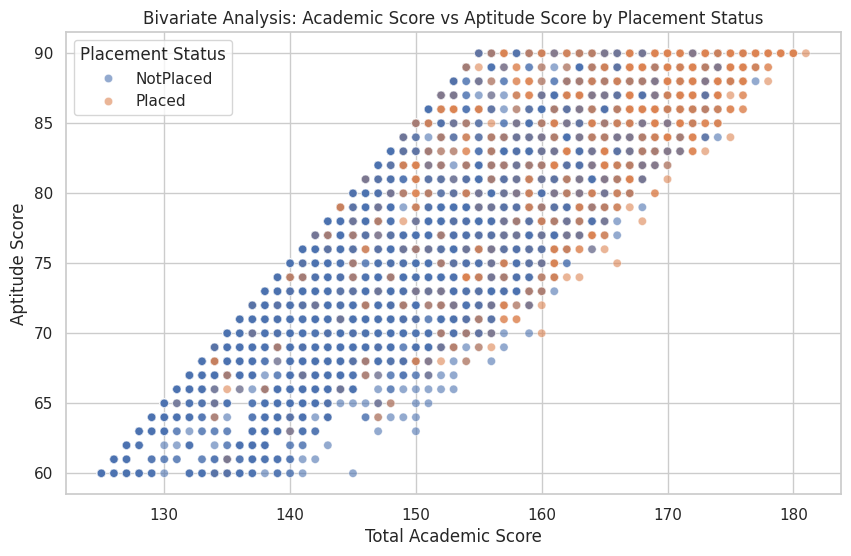

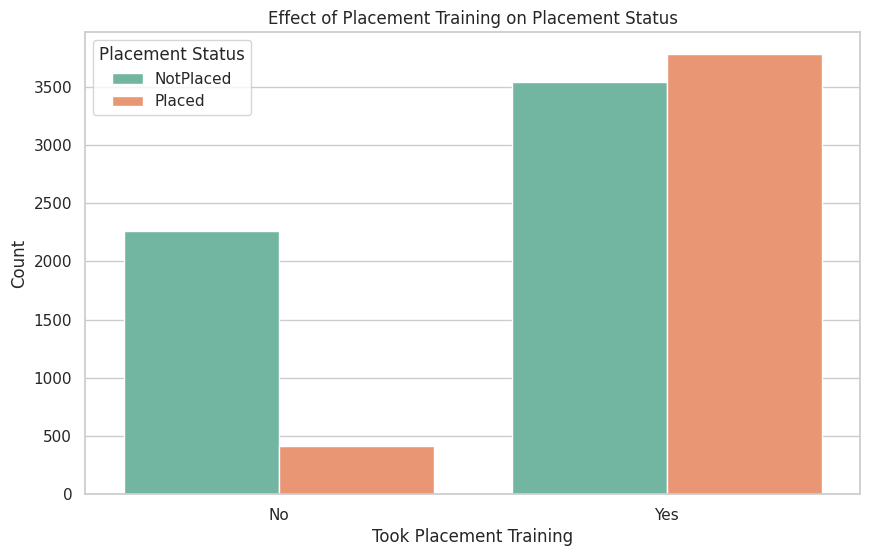

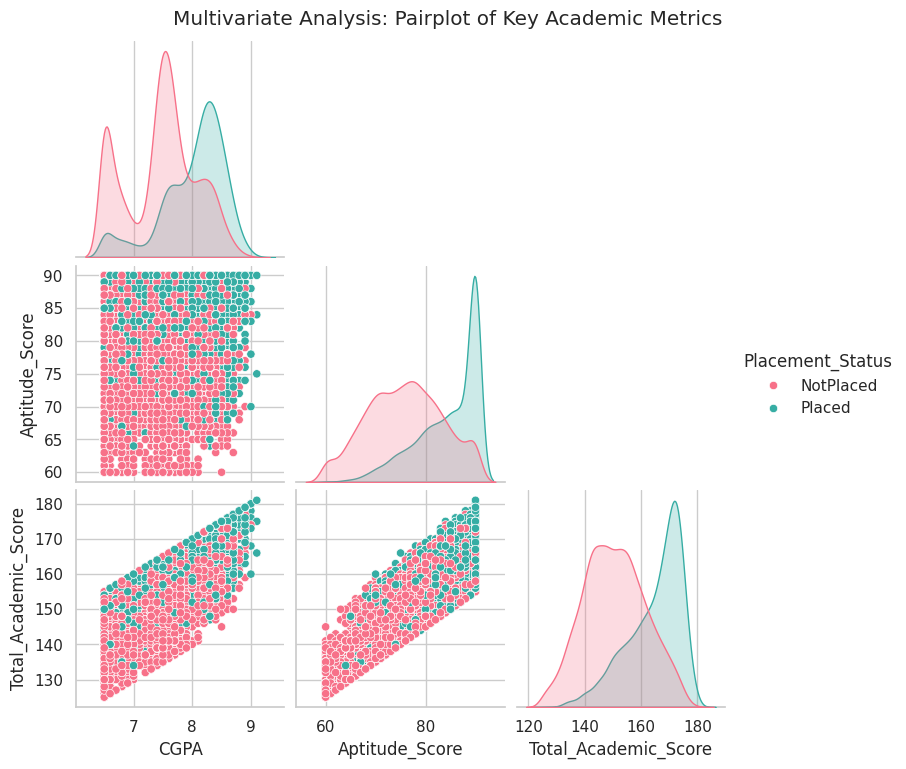

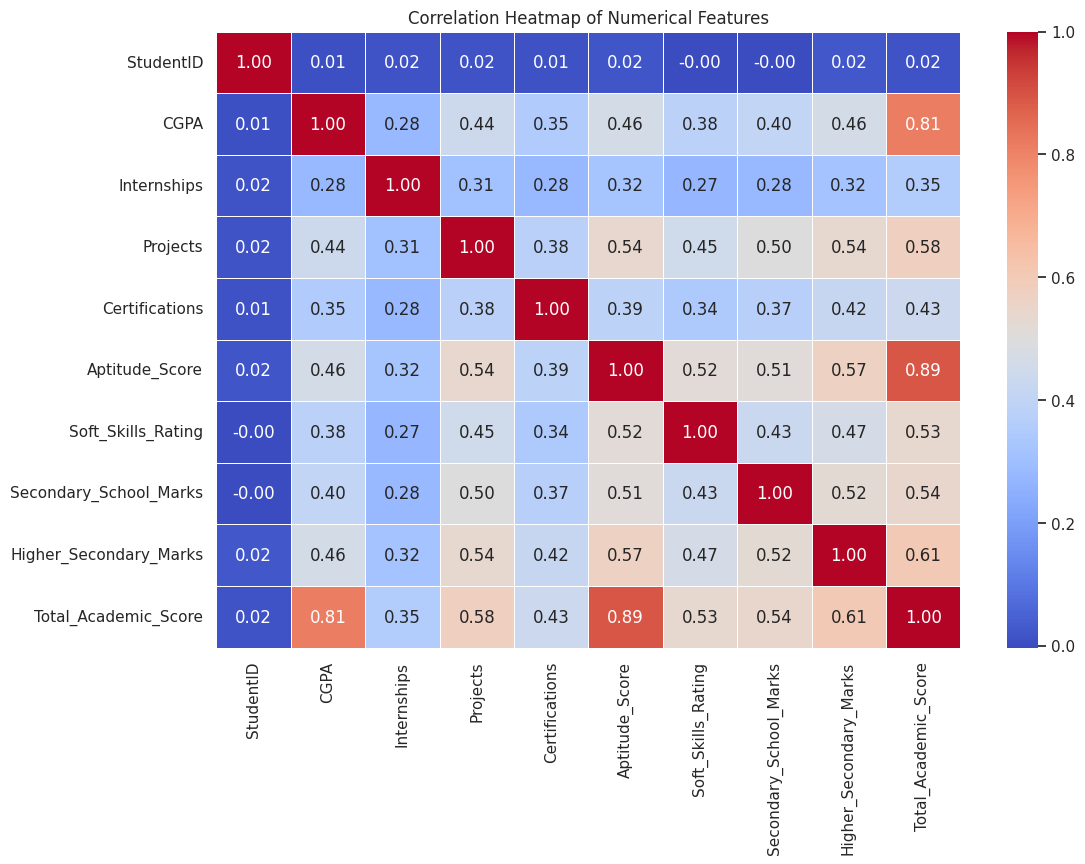

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set theme
sns.set_theme(style="whitegrid")

# 1. Scatter plot: Total_Academic_Score vs Aptitude_Score
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Total_Academic_Score', y='Aptitude_Score', hue='Placement_Status', alpha=0.6)
plt.title('Bivariate Analysis: Academic Score vs Aptitude Score by Placement Status')
plt.xlabel('Total Academic Score')
plt.ylabel('Aptitude Score')
plt.legend(title='Placement Status')
plt.show()

# 2. Bar plot (Count plot): Placement_Training vs Placement_Status
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Placement_Training', hue='Placement_Status', palette='Set2')
plt.title('Effect of Placement Training on Placement Status')
plt.xlabel('Took Placement Training')
plt.ylabel('Count')
plt.legend(title='Placement Status')
plt.show()

# 3. Pairplot for multi-variable distributions
# Selecting key numerical columns for the pairplot
subset_cols = ['CGPA', 'Aptitude_Score', 'Total_Academic_Score', 'Placement_Status']
sns.pairplot(df[subset_cols], hue='Placement_Status', corner=True, palette='husl')
plt.suptitle('Multivariate Analysis: Pairplot of Key Academic Metrics', y=1.02)
plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(12, 8))
# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numerical_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### **Summary of Key Trends and Placement Drivers**

Based on the Exploratory Data Analysis (EDA), several key insights regarding student placement outcomes have been identified:

1.  **Academic Performance is Paramount**: There is a strong positive correlation between **CGPA**, **Aptitude Score**, and **Total Academic Score**. Students with higher scores in these areas are significantly more likely to be 'Placed'.
2.  **Training Impact**: The analysis of **Placement Training** suggests that students who undergo specialized training programs show a higher frequency of successful placement compared to those who do not.
3.  **Skill Synergy**: The correlation heatmap indicates that while individual scores are important, the combination of strong academic results and soft skills contributes to a student's overall employability profile.
4.  **Data Distribution**: The pairplot reveals distinct clusters, suggesting that students with a CGPA above a certain threshold consistently fall into the 'Placed' category, making CGPA one of the most critical drivers for the predictive models.

## Predictive Modeling

### Subtask:
Implement and train Logistic Regression and Decision Tree models to predict student placement status and evaluate their performance.


Prepare the features and target variable by encoding categorical data, split the dataset into training and testing sets, and then train and evaluate both Logistic Regression and Decision Tree models as per the subtask instructions.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Prepare features (X) and target (y)
# Dropping StudentID as it's an identifier and Placement_Status as it's the target
X = df.drop(['StudentID', 'Placement_Status'], axis=1)
X = pd.get_dummies(X, drop_first=True)

# 2. Define target variable (y) - Encoding 'Placed' as 1 and 'NotPlaced' as 0
y = df['Placement_Status'].map({'Placed': 1, 'NotPlaced': 0})

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# 5. Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# 6. Evaluation and Comparison
def evaluate_model(name, y_true, y_pred):
    print(f'\n--- {name} Performance ---')
    print(f'Accuracy Score: {accuracy_score(y_true, y_pred):.4f}')
    print('Confusion Matrix:')
    print(confusion_matrix(y_true, y_pred))
    print('Classification Report:')
    print(classification_report(y_true, y_pred))

evaluate_model('Logistic Regression', y_test, y_pred_lr)
evaluate_model('Decision Tree', y_test, y_pred_dt)


--- Logistic Regression Performance ---
Accuracy Score: 0.7945
Confusion Matrix:
[[954 218]
 [193 635]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1172
           1       0.74      0.77      0.76       828

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.80      0.79      0.79      2000


--- Decision Tree Performance ---
Accuracy Score: 0.7280
Confusion Matrix:
[[883 289]
 [255 573]]
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.76      1172
           1       0.66      0.69      0.68       828

    accuracy                           0.73      2000
   macro avg       0.72      0.72      0.72      2000
weighted avg       0.73      0.73      0.73      2000



## Summary:

### **Q&A**

**What are the most critical factors for student placement success?**


The analysis identifies **CGPA**, **Total Academic Score**, and **Aptitude Score** as the most critical drivers. Students with higher scores in these metrics were significantly more likely to be placed.

Additionally, students who participated in **Placement Training** showed a higher frequency of successful placement compared to those who did not.

---

**How did the predictive models perform and which one was more effective?**
*   **Logistic Regression** achieved an accuracy of **79.45%** and demonstrated balanced precision and recall across both placed and non-placed categories.
*   **Decision Tree Classifier** achieved a lower accuracy of **72.80%**, with a higher rate of misclassifications.
*   **Conclusion:** The Logistic Regression model was more effective for this dataset.

---

### Data Analysis Key Findings

*   **Data Quality:** The dataset was cleaned by imputing missing numerical values with the median and categorical values with the mode. No duplicate rows were found.
*   **Outlier Detection:** Using the NumPy-based Interquartile Range (IQR) method, no outliers were detected in the `Total_Academic_Score` (IQR: 20.0, Bounds: 117.0 to 197.0), indicating a stable data distribution.
*   **Academic Correlation:** There is a strong positive linear relationship between CGPA and other academic scores. Visualizations (pairplots and heatmaps) confirmed that "Placed" students cluster heavily in the higher score brackets.
*   **Training Impact:** Descriptive statistics and count plots revealed that specialized placement training programs positively correlate with successful employment outcomes.
*   **Model Comparison:** Logistic Regression ($\approx$79.5% accuracy) outperformed the Decision Tree ($\approx$72.8% accuracy), suggesting that the relationship between features and placement status is better captured by a linear probabilistic model in this specific context.

---

### Insights or Next Steps

*   **Feature Engineering:** To improve model accuracy beyond 80%, future iterations could explore creating composite scores (e.g., combining Soft Skills and Academic scores) or applying feature scaling to numerical inputs.
*   **Model Refinement:** Given that the Decision Tree underperformed, hyperparameter tuning or utilizing ensemble methods like Random Forest might help capture non-linear relationships more effectively without overfitting.
